# Importing Modules

In [107]:
import floris
from floris import FlorisModel, TimeSeries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# Inputs

In [108]:
ti = 0.06           # m
d_wd = 1            # deg (Discretization Step)
d_ws = 1            # m/s (Discretization Step)

D = 130             # m
x = [0,0,0]         # m
y = [0, 5*D, 10*D]  # m


# Prepare the Wind Data

## Load from File

In [109]:
df = pd.read_csv("/home/lavender/Studies/Design of Wind Farms/Tutorial/Week4/sample_time_series.csv")

print(df.shape)

df.head()

(244080, 3)


,t_h,ws_HH_m/s,wd_HH_deg
0,0.0,6.374859,340.909111
1,0.5,6.369563,332.244448
2,1.0,6.577082,327.540863
3,1.5,7.023411,321.591873
4,2.0,7.194065,317.794319


## Extracting Data

In [110]:
wd = df.wd_HH_deg

wd.head()

0    340.909111
1    332.244448
2    327.540863
3    321.591873
4    317.794319
Name: wd_HH_deg, dtype: float64

In [111]:
ws = df["ws_HH_m/s"]

ws.head()

0    6.374859
1    6.369563
2    6.577082
3    7.023411
4    7.194065
Name: ws_HH_m/s, dtype: float64

In [112]:
ws = np.array(ws)
wd = np.array(wd)

print(ws.shape)

ws

(244080,)


array([ 6.37485934,  6.36956303,  6.57708181, ..., 20.72947294,
       21.84342605, 22.8937329 ], shape=(244080,))

## Initiate Floris

In [113]:
fmodel = FlorisModel("/home/lavender/Studies/Design of Wind Farms/Tutorial/Week4/gch.yaml")

## Create Floris TimeSeries

In [114]:
time_series = TimeSeries(wind_directions=wd, wind_speeds=ws, turbulence_intensities=ti)

In [ ]:
wind_rose = time_series.to_WindRose(wd_edges=np.arange(0,360,d_wd),
                                    ws_edges=np.arange(0,30,d_ws))

freq = wind_rose.freq_table

## Visualizing Wind Rose

In [116]:
freq[1]

array([4.54567995e-05, 1.03310908e-04, 1.57032580e-04, 1.77694762e-04,
       2.10754252e-04, 2.47946179e-04, 3.01667851e-04, 2.72740797e-04,
       2.89270542e-04, 3.59521960e-04, 2.72740797e-04, 2.81005670e-04,
       3.05800288e-04, 3.05800288e-04, 2.68608361e-04, 3.55389523e-04,
       2.56211052e-04, 1.69429889e-04, 2.23151561e-04, 1.52900144e-04,
       1.40502835e-04, 1.03310908e-04, 6.61189811e-05, 7.02514174e-05,
       5.37216721e-05, 4.54567995e-05, 3.30594906e-05, 3.71919269e-05,
       1.65297453e-05])

<PolarAxes: >

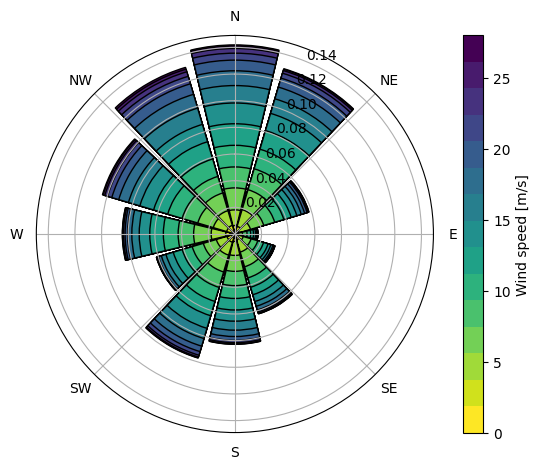

In [117]:
wind_rose.plot(wd_step=30, ws_step=2)

# Setting up Floris

In [118]:
fmodel.set(layout_x=x, layout_y=y, wind_data=wind_rose, turbine_type=["iea_3_4MW"])
fmodel.set(layout_x=x, layout_y=y, wind_data=wind_rose)

floris.floris_model.FlorisModel WARNING turbine_type has been changed without specifying a new reference_wind_height. reference_wind_height remains 90.00 m. Consider calling `FlorisModel.assign_hub_height_to_ref_height` to update the reference wind height to the turbine hub height.


# Running Floris

In [119]:
fmodel.run()

In [120]:
aep = fmodel.get_farm_AEP()

f"AEP from wind rose: {aep/1e9:.3f} (GWh)"

'AEP from wind rose: 58.176 (GWh)'

In [121]:
fmodel.run_no_wake()

aep_no_wake = fmodel.get_farm_AEP()

wakelosses = 100*((aep_no_wake-aep)/aep_no_wake)

f"{wakelosses:.3f} %"

'1.378 %'

# Random

In [122]:
# fmodel.set(layout_x=x, layout_y=y, wind_data=time_series)

# fmodel.run()


In [123]:
aep = fmodel.get_farm_AEP()

f"AEP from wind rose: {aep/1e9:.3f} (GWh)"

'AEP from wind rose: 58.989 (GWh)'